In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ==============================
# Cargar archivo CSV / OTUS desde ruta
# ==============================
FILE_PATH = r"C:\Users\josep\Documents\Proyectos\Proyectos_Python\Clustering_Microbiota\Datos\otu_data_converted.csv"   # <<< MODIFÍCALA AQUÍ

def load_dataframe_from_path(path):
    """
    Carga un DataFrame completo desde un archivo .csv o .otus.
    No filtra columnas.
    Retorna el DataFrame tal cual está en el archivo.
    """
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    ext = path.suffix.lower()

    if ext == ".csv":
        df = pd.read_csv(path, delimiter=",")
    elif ext == ".otus":
        df = pd.read_csv(path, sep="\t")  # Formato típico OTU
    else:
        raise ValueError(f"Formato no soportado: {ext}. Usa .csv o .otus")

    return df

# ==============================
# Carga del DataFrame completo
# ==============================
df = load_dataframe_from_path(FILE_PATH)
print(f"✅ Archivo cargado: {FILE_PATH}")
print(f"Shape del DataFrame: {df.shape}")
print(f"Columnas: {df.columns.tolist()[:10]}{' ...' if len(df.columns) > 10 else ''}")
df.head(10)

✅ Archivo cargado: C:\Users\josep\Documents\Proyectos\Proyectos_Python\Clustering_Microbiota\Datos\otu_data_converted.csv
Shape del DataFrame: (441, 4739)
Columnas: ['ID', 'Otu00001', 'Otu00002', 'Otu00003', 'Otu00004', 'Otu00005', 'Otu00006', 'Otu00007', 'Otu00008', 'Otu00009'] ...


,ID,Otu00001,Otu00002,Otu00003,Otu00004,Otu00005,Otu00006,Otu00007,Otu00008,Otu00009,...,Otu04757,Otu04758,Otu04759,Otu04760,Otu04761,Otu04762,Otu04763,Otu04764,Otu04765,Otu04766
0,MI_001_H,354,817,50,31,448,547,727,353,2,...,0,0,0,0,0,0,0,0,0,0
1,MI_002_H,168,9,131,3005,68,10187,570,2006,104,...,0,0,0,0,0,0,0,0,0,0
2,MI_003_H,19,174,6211,79,1063,0,6077,1852,1471,...,0,0,0,0,0,0,0,0,0,0
3,MI_004_H,264,1816,159,16,110,4,12,206,0,...,0,0,0,0,0,0,0,0,0,0
4,MI_005_H,0,2,0,12,598,39,0,0,1,...,0,0,0,0,0,0,0,0,0,0
5,MI_006_H,3,0,3536,38,815,1270,4085,1348,18,...,0,0,0,0,0,0,0,0,0,0
6,MI_007_H,0,1634,4767,85,6180,0,3455,5785,63,...,2,0,0,0,0,0,0,0,0,0
7,MI_008_H1,295,214,1915,4993,1568,20,164,574,97,...,0,0,0,0,0,0,0,0,0,0
8,MI_009_H,376,125,3308,9,61,647,448,8181,118,...,0,0,0,0,0,0,0,0,0,0
9,MI_010_H,370,2086,3301,52,2003,27,361,378,16,...,0,0,0,0,0,0,0,0,0,0


DataFrame original: (441, 4739) | Numérico: (441, 4738)
N total (finitos): 2089458 | Positivos: 105420


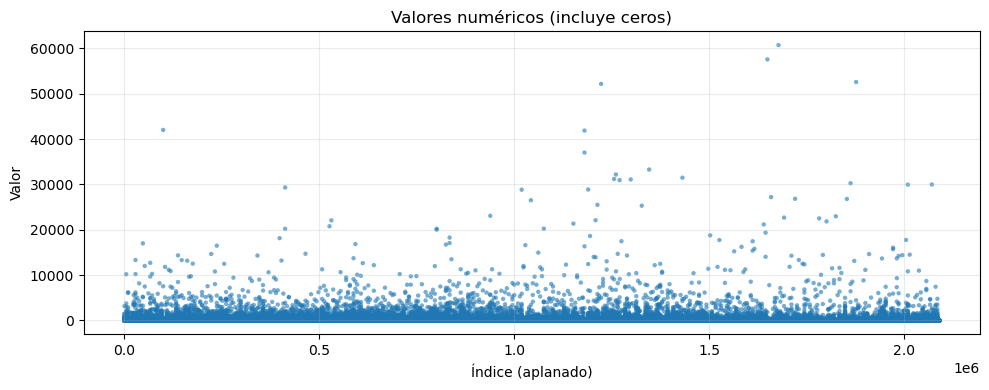

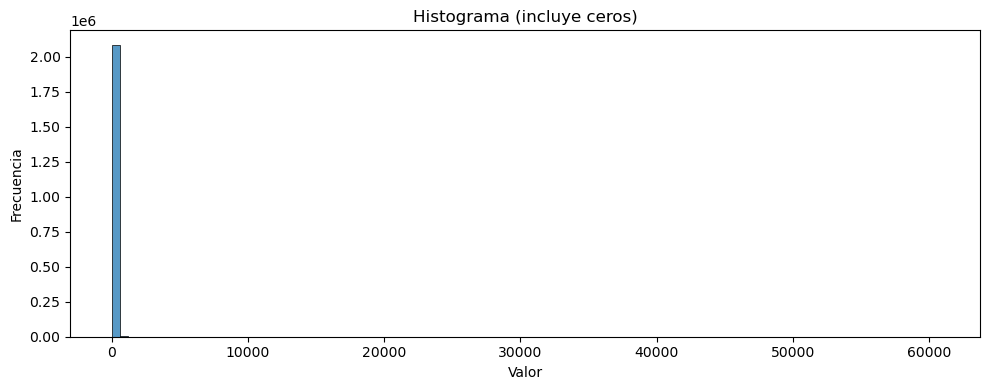

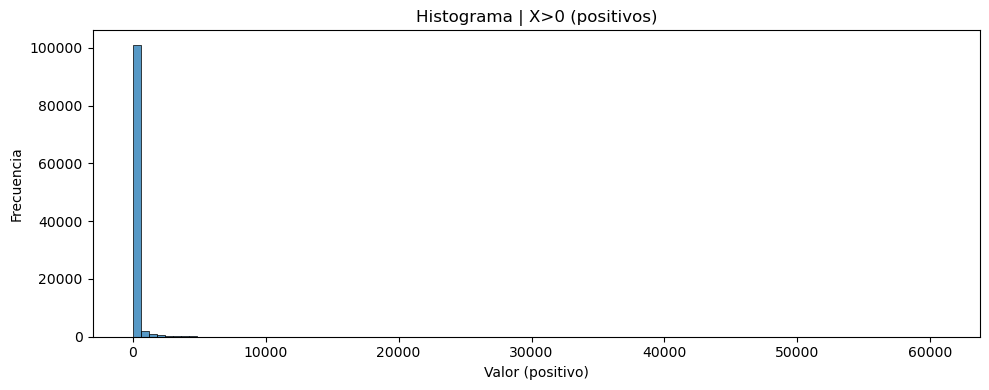

In [5]:
# =========================================
# EXTRACTO: Gráfico de dispersión + Histogramas
#   usando DataFrame (incluye ceros y opcionalmente solo positivos)
# =========================================

# df = tu DataFrame cargado completo
# (asegúrate de que df existe)

# 1) Tomar SOLO datos numéricos para graficar (sin perder df completo)
df_num = df.select_dtypes(include=[np.number])

if df_num.empty:
    raise ValueError("El DataFrame no contiene columnas numéricas para graficar.")

# 2) Aplanar valores
valores = df_num.to_numpy(dtype=float).ravel()
valores = valores[np.isfinite(valores)]  # seguridad por si hay NaN/inf
n = int(len(valores))

valores_pos = valores[valores > 0]
npos = int(len(valores_pos))

print(f"DataFrame original: {df.shape} | Numérico: {df_num.shape}")
print(f"N total (finitos): {n} | Positivos: {npos}")

# -----------------------------
# A) Gráfico de dispersión (incluye ceros)
# -----------------------------
plt.figure(figsize=(10, 4))
plt.scatter(np.arange(n), valores, s=10, alpha=0.6, edgecolor="none")
plt.title("Valores numéricos (incluye ceros)")
plt.xlabel("Índice (aplanado)")
plt.ylabel("Valor")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# -----------------------------
# B) Histograma (incluye ceros)
# -----------------------------
plt.figure(figsize=(10, 4))
sns.histplot(valores, bins=100, kde=False)
plt.title("Histograma (incluye ceros)")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# -----------------------------
# C) Histograma (solo positivos)
# -----------------------------
if npos > 0:
    plt.figure(figsize=(10, 4))
    sns.histplot(valores_pos, bins=100, kde=False)
    plt.title("Histograma | X>0 (positivos)")
    plt.xlabel("Valor (positivo)")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()
else:
    print("⚠ No hay valores positivos para graficar el histograma de X|X>0.")

In [6]:
# =========================================
# EXTRACTO: Reporte de información general (SIN gráficas) usando DataFrame
#   -> N total, ceros, positivos, min/max (solo numéricos finitos)
#   -> Columnas totalmente cero (en columnas numéricas)
# =========================================

# 1) Tomar columnas numéricas (sin perder df completo)
df_num = df.select_dtypes(include=[np.number])

if df_num.empty:
    raise ValueError("El DataFrame no contiene columnas numéricas para analizar.")

# 2) Aplanar y filtrar finitos
valores = df_num.to_numpy(dtype=float).ravel()
valores = valores[np.isfinite(valores)]
n = int(len(valores))

if n == 0:
    raise ValueError("No hay valores numéricos finitos en el DataFrame.")

n0 = int(np.sum(valores == 0))
npos = int(np.sum(valores > 0))
pi_hat = n0 / n

print(f"DataFrame original: {df.shape} | Numérico: {df_num.shape}")
print(f"N total (numéricos finitos): {n}")
print(f"Ceros:   {n0}  ({100*pi_hat:.2f}%)")
print(f"Positivos: {npos}  ({100*(1-pi_hat):.2f}%)")
print(f"Min: {valores.min():.4g}, Max: {valores.max():.4g}")

# 3) Columnas totalmente cero (solo en df_num)
# Nota: si hay NaN, una columna no será "todo-cero" a menos que todos sean 0 o NaN.
X_arr = df_num.to_numpy(dtype=float)
X_chk = np.where(np.isfinite(X_arr), X_arr, 0.0)  # tratar NaN/inf como 0 SOLO para este diagnóstico

cols_all_zero_mask = np.all(X_chk == 0, axis=0)
n_cols = int(df_num.shape[1])
n_cols_all_zero = int(np.sum(cols_all_zero_mask))
cols_all_zero_names = df_num.columns[cols_all_zero_mask].tolist()

print(f"\nColumnas numéricas totales: {n_cols}")
print(f"Columnas totalmente cero: {n_cols_all_zero} ({100*n_cols_all_zero/max(n_cols,1):.2f}%)")
if n_cols_all_zero > 0:
    print("Columnas todo-cero:")
    print(cols_all_zero_names)

# 4) Positivos
valores_pos = valores[valores > 0]

DataFrame original: (441, 4739) | Numérico: (441, 4738)
N total (numéricos finitos): 2089458
Ceros:   1984038  (94.95%)
Positivos: 105420  (5.05%)
Min: 0, Max: 6.071e+04

Columnas numéricas totales: 4738
Columnas totalmente cero: 18 (0.38%)
Columnas todo-cero:
['Otu01865', 'Otu02428', 'Otu03125', 'Otu03184', 'Otu03192', 'Otu03260', 'Otu03353', 'Otu03445', 'Otu03510', 'Otu03554', 'Otu03688', 'Otu03761', 'Otu03816', 'Otu04211', 'Otu04309', 'Otu04606', 'Otu04675', 'Otu04684']


In [ ]:
# =========================================
# EXTRACTO: Anderson–Darling (SIN MUESTREO) usando DataFrame df para:
#   - norm, logistic, gumbel_l, gumbel_r  (sobre TODOS los datos: incluye ceros)
#   - norm, expon, logistic, gumbel_l, gumbel_r (sobre X>0)
#   - lognormal (vía anderson sobre log(X>0) vs Normal)
#   + gamma (vía ajuste MLE + KS y/o Cramér–von Mises) sobre X>0
# =========================================

import numpy as np
from scipy.stats import anderson
from scipy import stats  # gamma.fit, kstest, cramervonmises

# -----------------------------
# 0. Parámetros
# -----------------------------
ALPHA = 0.05   # <-- cambia aquí (ej: 0.01, 0.10, etc.)

# -----------------------------
# 1. Preparar datos desde df
# -----------------------------
# df = DataFrame completo cargado

# Si NO quieres incluir una columna ID numérica, descomenta:
# df_num = df.drop(columns=["ID"], errors="ignore").select_dtypes(include=[np.number])

df_num = df.select_dtypes(include=[np.number])

if df_num.empty:
    raise ValueError("El DataFrame no tiene columnas numéricas para ejecutar las pruebas.")

valores = df_num.to_numpy(dtype=float).ravel()
valores = valores[np.isfinite(valores)]

n_all = int(len(valores))
n0 = int(np.sum(valores == 0))
npos = int(np.sum(valores > 0))

valores_pos = valores[valores > 0]

# -----------------------------
# Utilidad interna para imprimir igual
# -----------------------------
def _print_anderson_block(data, dist_code, header, ALPHA):
    ad = anderson(data, dist=dist_code)
    print(f"\n{header}")
    print(f"  AD stat = {ad.statistic:.4f}")

    alpha_pct = 100 * ALPHA
    levels = np.asarray(ad.significance_level, dtype=float)  # [15, 10, 5, 2.5, 1]
    crits  = np.asarray(ad.critical_values, dtype=float)

    idx_near = int(np.argmin(np.abs(levels - alpha_pct)))
    level_used = float(levels[idx_near])
    crit_used  = float(crits[idx_near])

    for sl, cv in zip(levels, crits):
        print(f"  crit @ {sl:4.1f}%: {cv:.4f}")

    if ad.statistic > crit_used:
        print(f"  Decisión (≈α={ALPHA}, usando crítico {level_used}%): SE rechaza (AD > crit).")
    else:
        print(f"  Decisión (≈α={ALPHA}, usando crítico {level_used}%): NO se rechaza (AD ≤ crit).")

# -----------------------------
# Gamma GOF (MLE + KS + CvM) sobre X>0
# -----------------------------
def _print_gamma_gof(data_pos, ALPHA):
    print("\nGamma de X>0 (Ajuste MLE + KS/CvM):")

    if len(data_pos) == 0:
        print("  ⚠ No hay datos positivos para ajustar Gamma.")
        return

    # Ajuste MLE (Gamma estándar con soporte x>0)
    a, loc, scale = stats.gamma.fit(data_pos, floc=0)

    print(f"  Parámetros MLE: shape(a)={a:.6g}, loc={loc:.6g}, scale={scale:.6g}")

    ks = stats.kstest(data_pos, 'gamma', args=(a, loc, scale))
    print(f"  KS stat = {ks.statistic:.4f}")
    print(f"  KS p-value = {ks.pvalue:.4g}")
    if ks.pvalue < ALPHA:
        print(f"  Decisión KS (α={ALPHA}): SE rechaza gamma (p < α).")
    else:
        print(f"  Decisión KS (α={ALPHA}): NO se rechaza gamma (p ≥ α).")

    cvm = stats.cramervonmises(data_pos, 'gamma', args=(a, loc, scale))
    print(f"  CvM stat = {cvm.statistic:.4f}")
    print(f"  CvM p-value = {cvm.pvalue:.4g}")
    if cvm.pvalue < ALPHA:
        print(f"  Decisión CvM (α={ALPHA}): SE rechaza gamma (p < α).")
    else:
        print(f"  Decisión CvM (α={ALPHA}): NO se rechaza gamma (p ≥ α).")

# -----------------------------
# 2) Anderson-Darling en TODOS los datos (incluye ceros)
# -----------------------------
dists_all = [
    ("norm",     "Normalidad de X (incluye ceros) (Anderson-Darling, muestra):"),
    ("logistic", "Logística de X (incluye ceros) (Anderson-Darling, muestra):"),
    ("gumbel_l", "Gumbel (izq) de X (incluye ceros) (Anderson-Darling, muestra):"),
    ("gumbel_r", "Gumbel (der) de X (incluye ceros) (Anderson-Darling, muestra):"),
]

if n_all == 0:
    print("⚠ No hay datos numéricos finitos en df.")
else:
    for dist_code, header in dists_all:
        _print_anderson_block(valores, dist_code, header, ALPHA)

# -----------------------------
# 3) Anderson-Darling en positivos (X>0)
# -----------------------------
if npos == 0:
    print("⚠ No hay valores positivos. No tiene sentido ajustar lognormal/gamma/expon.")
else:
    dists_pos = [
        ("norm",     "Normalidad de X>0 (Anderson-Darling, muestra):"),
        ("expon",    "Exponencialidad de X>0 (Anderson-Darling, muestra):"),
        ("logistic", "Logística de X>0 (Anderson-Darling, muestra):"),
        ("gumbel_l", "Gumbel (izq) de X>0 (Anderson-Darling, muestra):"),
        ("gumbel_r", "Gumbel (der) de X>0 (Anderson-Darling, muestra):"),
    ]

    for dist_code, header in dists_pos:
        _print_anderson_block(valores_pos, dist_code, header, ALPHA)

    # 3.1) Gamma GOF
    _print_gamma_gof(valores_pos, ALPHA)

    # -----------------------------
    # 4) Lognormalidad: X lognormal <=> log(X) normal
    # -----------------------------
    log_vals = np.log(valores_pos)
    log_vals = log_vals[np.isfinite(log_vals)]

    ad_ln = anderson(log_vals, dist="norm")
    print("\nLognormalidad de X (Anderson-Darling sobre log(X>0) vs Normal, muestra):")
    print(f"  AD stat = {ad_ln.statistic:.4f}")

    alpha_pct = 100 * ALPHA
    levels = np.asarray(ad_ln.significance_level, dtype=float)
    crits  = np.asarray(ad_ln.critical_values, dtype=float)

    idx_near = int(np.argmin(np.abs(levels - alpha_pct)))
    level_used = float(levels[idx_near])
    crit_used  = float(crits[idx_near])

    for sl, cv in zip(levels, crits):
        print(f"  crit @ {sl:4.1f}%: {cv:.4f}")

    if ad_ln.statistic > crit_used:
        print(f"  Decisión (≈α={ALPHA}, usando crítico {level_used}%): SE rechaza lognormalidad (AD > crit).")
    else:
        print(f"  Decisión (≈α={ALPHA}, usando crítico {level_used}%): NO se rechaza lognormalidad (AD ≤ crit).")


Normalidad de X (incluye ceros) (Anderson-Darling, muestra):
  AD stat = 781495.7745
  crit @ 15.0%: 0.5760
  crit @ 10.0%: 0.6560
  crit @  5.0%: 0.7870
  crit @  2.5%: 0.9180
  crit @  1.0%: 1.0920
  Decisión (≈α=0.05, usando crítico 5.0%): SE rechaza (AD > crit).


C:\Users\josep\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:2232: RuntimeWarning: overflow encountered in exp
  tmp2 = exp(tmp)
C:\Users\josep\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:2234: RuntimeWarning: overflow encountered in multiply
  np.sum(tmp*(1.0-tmp2)/(1+tmp2), axis=0) + N]
C:\Users\josep\anaconda3\Lib\site-packages\scipy\stats\_morestats.py:2234: RuntimeWarning: invalid value encountered in divide
  np.sum(tmp*(1.0-tmp2)/(1+tmp2), axis=0) + N]



Logística de X (incluye ceros) (Anderson-Darling, muestra):
  AD stat = 4941916.7600
  crit @ 25.0%: 0.4260
  crit @ 10.0%: 0.5630
  crit @  5.0%: 0.6600
  crit @  2.5%: 0.7690
  crit @  1.0%: 0.9060
  crit @  0.5%: 1.0100
  Decisión (≈α=0.05, usando crítico 5.0%): SE rechaza (AD > crit).

Gumbel (izq) de X (incluye ceros) (Anderson-Darling, muestra):
  AD stat = 882488.0804
  crit @ 25.0%: 0.4740
  crit @ 10.0%: 0.6370
  crit @  5.0%: 0.7570
  crit @  2.5%: 0.8770
  crit @  1.0%: 1.0380
  Decisión (≈α=0.05, usando crítico 5.0%): SE rechaza (AD > crit).

Gumbel (der) de X (incluye ceros) (Anderson-Darling, muestra):
  AD stat = inf
  crit @ 25.0%: 0.4740
  crit @ 10.0%: 0.6370
  crit @  5.0%: 0.7570
  crit @  2.5%: 0.8770
  crit @  1.0%: 1.0380
  Decisión (≈α=0.05, usando crítico 5.0%): SE rechaza (AD > crit).

Normalidad de X>0 (Anderson-Darling, muestra):
  AD stat = 31514.2886
  crit @ 15.0%: 0.5760
  crit @ 10.0%: 0.6560
  crit @  5.0%: 0.7870
  crit @  2.5%: 0.9180
  crit @  1.0%

In [ ]:
# =========================================
# EXTRACTO: Comparación por BIC (SOLO positivos + HURDLE total) - SIN MUESTREO
#   usando DataFrame df
# =========================================

import numpy as np
import pandas as pd
from scipy.stats import lognorm, gamma, expon
from statsmodels.tools.eval_measures import bic as sm_bic

# -----------------------------
# 1) Preparar datos desde df
# -----------------------------
# df = DataFrame completo cargado

# Si NO quieres incluir una columna ID numérica, descomenta:
# df_num = df.drop(columns=["ID"], errors="ignore").select_dtypes(include=[np.number])

df_num = df.select_dtypes(include=[np.number])

if df_num.empty:
    raise ValueError("El DataFrame no tiene columnas numéricas para ajustar distribuciones.")

# Aplanar + filtrar finitos
valores = df_num.to_numpy(dtype=float).ravel()
valores = valores[np.isfinite(valores)]
n = int(len(valores))

if n == 0:
    raise ValueError("No hay valores numéricos finitos en df para evaluar.")

n0 = int(np.sum(valores == 0))
npos = int(np.sum(valores > 0))
pi_hat = (n0 / n) if n > 0 else np.nan

valores_pos = valores[valores > 0]

print(f"DataFrame original: {df.shape} | Numérico usado: {df_num.shape}")
print(f"N finitos={n} | ceros={n0} | positivos={npos} | pi_hat={pi_hat:.6g}")

if npos == 0:
    print("⚠ No hay valores positivos. No tiene sentido ajustar lognormal/gamma/expon.")
else:
    # SIN MUESTREO: usamos TODOS los positivos
    data_fit = valores_pos

    # ----- Ajustes (solo positivos) -----
    # Lognormal (floc=0)
    sigma_ln, loc_ln, scale_ln = lognorm.fit(data_fit, floc=0)
    ll_ln = float(np.sum(lognorm.logpdf(data_fit, sigma_ln, loc=loc_ln, scale=scale_ln)))
    mu_ln = float(np.log(scale_ln))
    params_ln = (mu_ln, float(sigma_ln), float(loc_ln), float(scale_ln))

    # Gamma (floc=0)
    a_g, loc_g, scale_g = gamma.fit(data_fit, floc=0)
    ll_g = float(np.sum(gamma.logpdf(data_fit, a_g, loc=loc_g, scale=scale_g)))
    params_g = (float(a_g), float(loc_g), float(scale_g))

    # Expon (floc=0)
    loc_e, scale_e = expon.fit(data_fit, floc=0)
    ll_e = float(np.sum(expon.logpdf(data_fit, loc=loc_e, scale=scale_e)))
    params_e = (float(loc_e), float(scale_e))

    # Info criteria para SOLO positivos (SOLO BIC)
    rows_pos = [
        {"modelo_pos": "pos_lognormal", "BIC_pos": sm_bic(ll_ln, len(data_fit), 2)},
        {"modelo_pos": "pos_gamma",     "BIC_pos": sm_bic(ll_g,  len(data_fit), 2)},
        {"modelo_pos": "pos_expon",     "BIC_pos": sm_bic(ll_e,  len(data_fit), 1)},
    ]

    df_pos = pd.DataFrame(rows_pos).sort_values("BIC_pos")
    print("\nComparación SOLO positivos (componente continuo):")
    try:
        display(df_pos)  # Jupyter
    except NameError:
        print(df_pos.to_string(index=False))

    best_pos = df_pos.iloc[0]["modelo_pos"]
    print(f"➜ Mejor en positivos por BIC: {best_pos}")

    # ----- Modelos TOTAL (HURDLE) (SOLO BIC) -----
    pi_clip = float(np.clip(pi_hat, 1e-12, 1 - 1e-12))
    ll_hurdle_base = float(n0 * np.log(pi_clip) + len(data_fit) * np.log(1.0 - pi_clip))

    total_rows = [
        {
            "modelo_total": "hurdle_lognormal",
            "BIC_total": sm_bic(ll_hurdle_base + ll_ln, n0 + len(data_fit), 3),  # k = 1(pi) + 2(positivo)
            "pi_hat": pi_hat,
            "params": params_ln
        },
        {
            "modelo_total": "hurdle_gamma",
            "BIC_total": sm_bic(ll_hurdle_base + ll_g, n0 + len(data_fit), 3),   # k = 1(pi) + 2(positivo)
            "pi_hat": pi_hat,
            "params": params_g
        },
        {
            "modelo_total": "hurdle_expon",
            "BIC_total": sm_bic(ll_hurdle_base + ll_e, n0 + len(data_fit), 2),   # k = 1(pi) + 1(positivo)
            "pi_hat": pi_hat,
            "params": params_e
        },
    ]

    df_total = pd.DataFrame(total_rows).sort_values("BIC_total")
    print("\nComparación TOTAL (hurdle: incluye masa en cero + positivos):")
    try:
        display(df_total)  # Jupyter
    except NameError:
        print(df_total.to_string(index=False))

    best_total = df_total.iloc[0]["modelo_total"]
    print(f"➜ Mejor modelo TOTAL por BIC: {best_total}")

DataFrame original: (441, 4739) | Numérico usado: (441, 4738)
N finitos=2089458 | ceros=1984038 | positivos=105420 | pi_hat=0.949547

Comparación SOLO positivos (componente continuo):


,modelo_pos,BIC_pos
0,pos_lognormal,9.510464e+05
1,pos_gamma,1.039826e+06
2,pos_expon,1.252628e+06


➜ Mejor en positivos por BIC: pos_lognormal

Comparación TOTAL (hurdle: incluye masa en cero + positivos):


,modelo_total,BIC_total,pi_hat,params
0,hurdle_lognormal,1.786214e+06,0.949547,"(2.421416919873371, 1.9547925104016337, 0.0, 1..."
1,hurdle_gamma,1.874993e+06,0.949547,"(0.27721857931517724, 0.0, 504.73086757865093)"
2,hurdle_expon,2.087793e+06,0.949547,"(0.0, 139.92077404667046)"


➜ Mejor modelo TOTAL por BIC: hurdle_lognormal


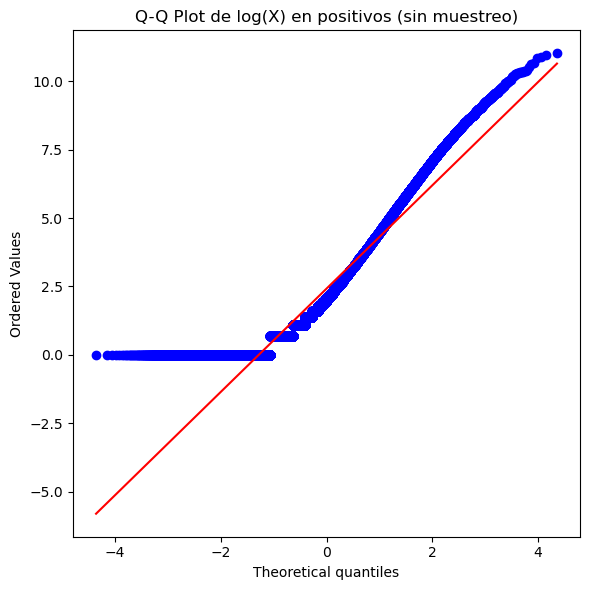

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot

# --- Datos desde DataFrame df (SIN muestreo) ---
# Si NO quieres incluir una columna ID numérica, descomenta:
# df_num = df.drop(columns=["ID"], errors="ignore").select_dtypes(include=[np.number])

df_num = df.select_dtypes(include=[np.number])

if df_num.empty:
    raise ValueError("El DataFrame no tiene columnas numéricas para el Q-Q plot.")

valores = df_num.to_numpy(dtype=float).ravel()
valores = valores[np.isfinite(valores)]  # por seguridad

valores_pos = valores[valores > 0]
npos = int(len(valores_pos))

if npos == 0:
    raise ValueError("No hay valores positivos para hacer Q-Q plot de log(X).")

# --- Transformación para lognormalidad (SIN muestreo) ---
log_vals = np.log(valores_pos)
log_vals = log_vals[np.isfinite(log_vals)]

# --- Q-Q plot usando scipy ---
fig = plt.figure(figsize=(6, 6))
probplot(log_vals, dist="norm", plot=plt)
plt.title("Q-Q Plot de log(X) en positivos (sin muestreo)")
plt.tight_layout()
plt.show()

KDE sobre positivos los datos
N = 105420, min=1, max=6.071e+04
Parámetros: bw_method=scott, cut=0, xscale=log


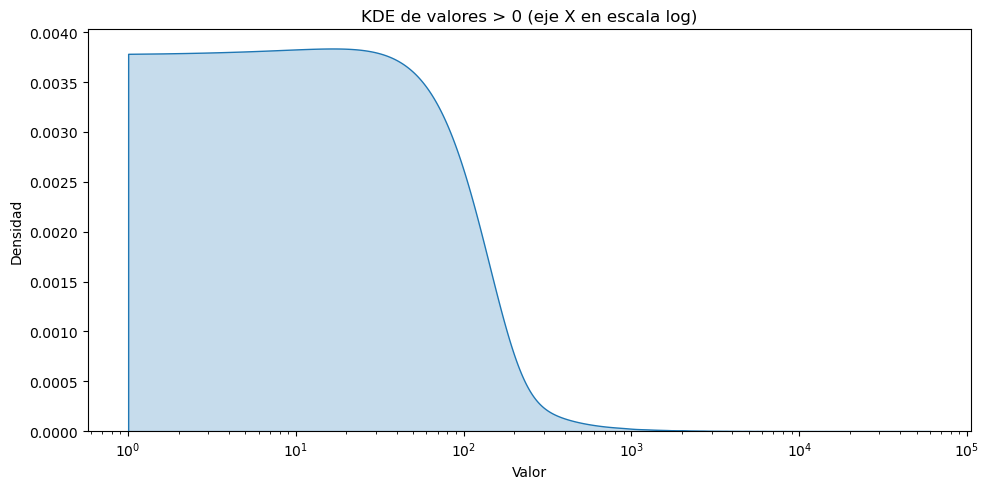

In [ ]:
# =========================================
# KDE (Kernel Density Estimation) sobre df
#   - Permite: todos vs positivos
#   - Permite: eje X en escala lineal o log
#   - SIN muestreo
# =========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# 0) Parámetros (ajusta aquí)
# -----------------------------
usar_solo_positivos = True      # True -> solo X>0 ; False -> todos (incluye ceros y negativos si existieran)
usar_escala_log_x   = True      # True -> eje X log (requiere X>0)
bw_method = "scott"         # "scott", "silverman" o número (ej. 0.3)
cut = 0                         # evita extender fuera del rango
figsize = (10, 5)

# -----------------------------
# 1) Preparar datos desde DataFrame df
# -----------------------------
# Si NO quieres incluir una columna ID numérica, descomenta:
# df_num = df.drop(columns=["ID"], errors="ignore").select_dtypes(include=[np.number])

df_num = df.select_dtypes(include=[np.number])

if df_num.empty:
    raise ValueError("El DataFrame no tiene columnas numéricas para KDE.")

valores = df_num.to_numpy(dtype=float).ravel()
valores = valores[np.isfinite(valores)]

valores_pos = valores[valores > 0]

# Si vas a usar escala log, forzar positivos
if usar_escala_log_x:
    usar_solo_positivos = True

data_kde = valores_pos if usar_solo_positivos else valores

if len(data_kde) == 0:
    raise ValueError("No hay datos para KDE con la selección actual.")

print(f"KDE sobre {'positivos' if usar_solo_positivos else 'todos'} los datos")
print(f"N = {len(data_kde)}, min={data_kde.min():.4g}, max={data_kde.max():.4g}")
print(f"Parámetros: bw_method={bw_method}, cut={cut}, xscale={'log' if usar_escala_log_x else 'linear'}")

# -----------------------------
# 2) KDE con seaborn
# -----------------------------
fig, ax = plt.subplots(figsize=figsize)

sns.kdeplot(
    data_kde,
    fill=True,
    bw_method=bw_method,
    gridsize=100000,
    cut=cut,
    ax=ax
)

if usar_escala_log_x:
    ax.set_xscale("log")

titulo = "KDE de valores > 0" if usar_solo_positivos else "KDE de todos los valores"
if usar_escala_log_x:
    titulo += " (eje X en escala log)"

ax.set_title(titulo)
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
plt.tight_layout()
plt.show()

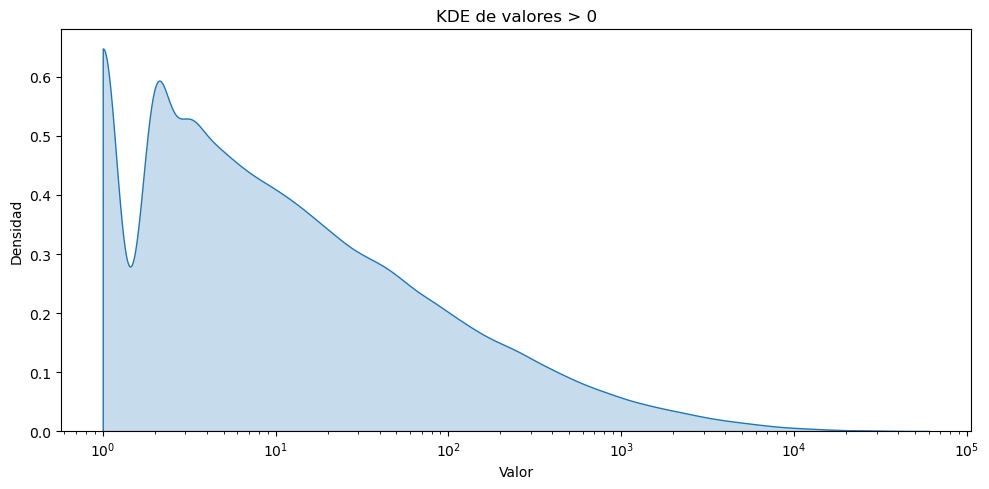

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# KDE desde DataFrame df (SIN muestreo)
# -----------------------------
# Si NO quieres incluir una columna ID numérica, descomenta:
# df_num = df.drop(columns=["ID"], errors="ignore").select_dtypes(include=[np.number])

df_num = df.select_dtypes(include=[np.number])
if df_num.empty:
    raise ValueError("El DataFrame no tiene columnas numéricas para KDE.")

valores = df_num.to_numpy(dtype=float).ravel()
valores = valores[np.isfinite(valores)]
data_kde = valores[valores > 0]

if len(data_kde) == 0:
    raise ValueError("No hay datos positivos.")

fig, ax = plt.subplots(figsize=(10, 5))

# Dibujar KDE (sin cálculo de área)
sns.kdeplot(
    data_kde,
    fill=True,          
    bw_method="silverman",
    cut=0,
    log_scale=True,     
    gridsize=100000,
    ax=ax
)

ax.set_title("KDE de valores > 0")
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
plt.tight_layout()
plt.show()

Área KDE (integrada en x) ≈ 0.619464


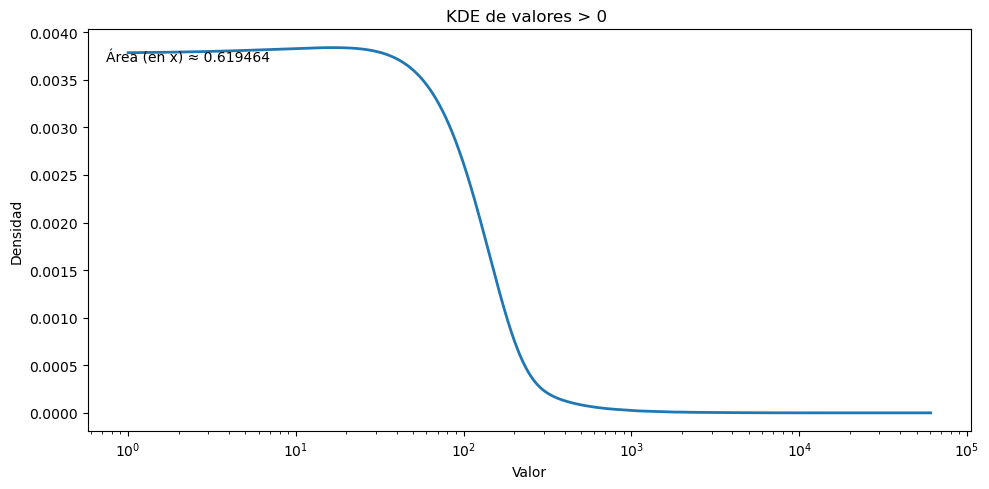

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# 0) Preparar datos
valores = X.flatten().astype(float)
valores = valores[np.isfinite(valores)]
data_kde = valores[valores > 0]

if len(data_kde) == 0:
    raise ValueError("No hay datos positivos.")

# 1) KDE numérico (Gaussian KDE) con regla de Scott (equivalente a bw_method="scott")
kde = gaussian_kde(data_kde, bw_method="scott")

# 2) Malla en x (log-espaciada para cubrir bien colas largas, PERO integraremos en x)
x_grid = np.logspace(np.log10(data_kde.min()), np.log10(data_kde.max()), 4000)
y_grid = kde(x_grid)

# 3) Área bajo la densidad respecto a x
area = float(np.trapezoid(y_grid, x_grid))
print(f"Área KDE (integrada en x) ≈ {area:.6f}")

# 4) Graficar (seaborn para estética + nuestra curva para control)
fig, ax = plt.subplots(figsize=(10, 5))

# KDE de seaborn (solo para visualizar)
#sns.kdeplot(data_kde, fill=True, bw_method="scott", cut=0, log_scale=True, gridsize=2000, ax=ax)

# Nuestra curva (misma densidad calculada) para comparar
ax.plot(x_grid, y_grid, linewidth=2)

ax.text(0.02, 0.95, f"Área (en x) ≈ {area:.6f}", transform=ax.transAxes, va="top")
ax.set_xscale("log")
ax.set_title("KDE de valores > 0 ")
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
plt.tight_layout()
plt.show()

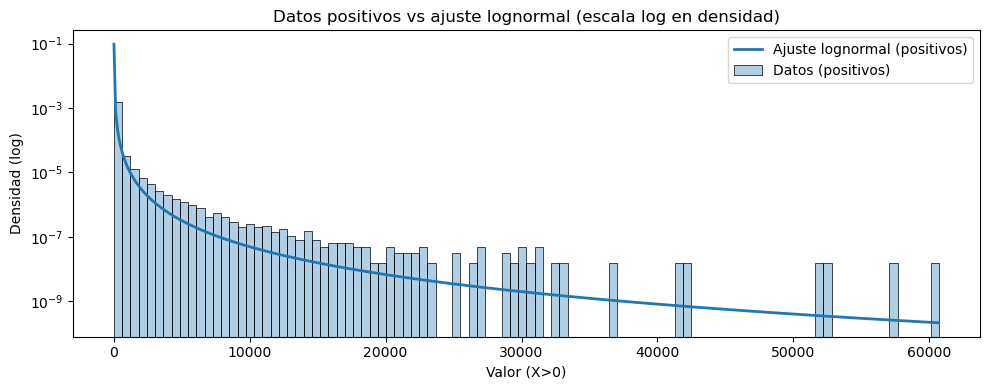

In [ ]:
# =========================================
# EXTRACTO: Datos positivos vs ajuste LOGNORMAL
#   (histograma en densidad + curva PDF lognormal ajustada)
# =========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm

# 1) Preparar datos (mismo criterio del bloque)
X_arr = np.asarray(X, dtype=float)
valores = X_arr.flatten()
valores_pos = valores[valores > 0]

if len(valores_pos) == 0:
    raise ValueError("⚠ No hay valores positivos para ajustar lognormal.")

# (Opcional) limitar puntos para que el ajuste sea manejable en datasets enormes
#MAX_FIT = 20000
#rng = np.random.default_rng(123)
#data_fit = valores_pos if len(valores_pos) <= MAX_FIT else rng.choice(valores_pos, size=MAX_FIT, replace=False)
data_fit=valores_pos

# 2) Ajuste lognormal (soporte positivo)
sigma, loc, scale = lognorm.fit(data_fit, floc=0)

# 3) Curva ajustada vs histograma (solo positivos)
xgrid = np.linspace(valores_pos.min(), valores_pos.max(), 500)

plt.figure(figsize=(10, 4))
sns.histplot(valores_pos, bins=100, stat="density", alpha=0.35, label="Datos (positivos)")
pdf = lognorm.pdf(xgrid, sigma, loc=loc, scale=scale)
plt.plot(xgrid, pdf, linewidth=2, label="Ajuste lognormal (positivos)")

plt.yscale("log")  # escala log en densidad (como tu bloque)
plt.title("Datos positivos vs ajuste lognormal (escala log en densidad)")
plt.xlabel("Valor (X>0)")
plt.ylabel("Densidad (log)")
plt.legend()
plt.tight_layout()
plt.show()


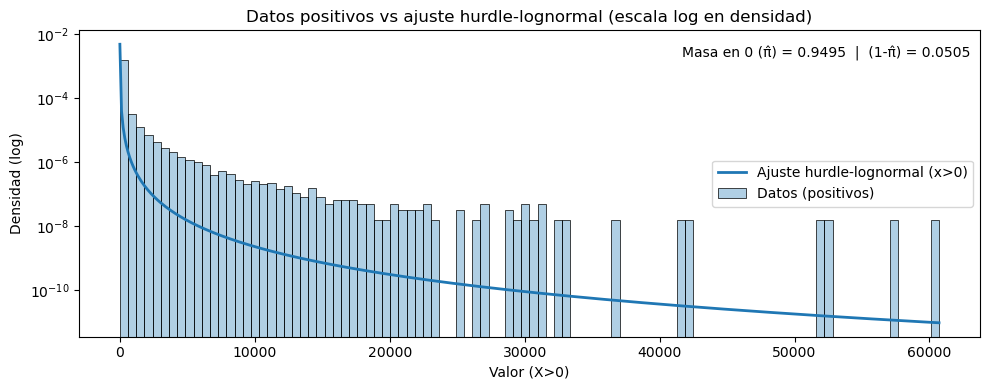

In [ ]:
# =========================================
# EXTRACTO: Datos positivos vs ajuste HURDLE-LOGNORMAL
#   - Histograma densidad de X>0
#   - Curva del modelo hurdle en x>0: (1 - pi_hat) * pdf_lognormal(x)
#   - Reporta la masa en cero pi_hat (anotación)
# =========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm

# 1) Preparar datos
X_arr = np.asarray(X, dtype=float)
valores = X_arr.flatten()
valores_pos = valores[valores > 0]

n = len(valores)
n0 = int(np.sum(valores == 0))
pi_hat = n0 / n if n > 0 else np.nan  # masa estimada en 0

if len(valores_pos) == 0:
    raise ValueError("⚠ No hay valores positivos para ajustar hurdle-lognormal.")

data_fit=valores_pos
# 2) Ajuste lognormal del componente positivo (soporte positivo)
sigma, loc, scale = lognorm.fit(data_fit, floc=0)

# 3) Curva hurdle vs histograma (solo positivos)
xgrid = np.linspace(valores_pos.min(), valores_pos.max(), 500)

plt.figure(figsize=(10, 4))
sns.histplot(valores_pos, bins=100, stat="density", alpha=0.35, label="Datos (positivos)")

pdf_pos = lognorm.pdf(xgrid, sigma, loc=loc, scale=scale)          # pdf condicional del componente positivo
pdf_hurdle = (1.0 - pi_hat) * pdf_pos                              # densidad *no-condicional* para x>0

plt.plot(xgrid, pdf_hurdle, linewidth=2, label="Ajuste hurdle-lognormal (x>0)")

plt.yscale("log")  # escala log en densidad
plt.title("Datos positivos vs ajuste hurdle-lognormal (escala log en densidad)")
plt.xlabel("Valor (X>0)")
plt.ylabel("Densidad (log)")
plt.legend()

# Anotación de la masa en cero (no es densidad continua)
plt.text(
    0.99, 0.95,
    f"Masa en 0 (π̂) = {pi_hat:.4f}  |  (1-π̂) = {1.0-pi_hat:.4f}",
    ha="right", va="top",
    transform=plt.gca().transAxes
)

plt.tight_layout()
plt.show()


In [ ]:

# ==============================
# Bloque 2: Normalización [0,1]
# ==============================
X_min = float(np.min(X))
X_max = float(np.max(X))
if X_max == X_min:
    X_norm = np.ones_like(X)
else:
    X_norm = (X - X_min) / (X_max - X_min)

print(f"Normalización: min={X_min:.6g}, max={X_max:.6g}")
print(f"Rango X_norm -> [{X_norm.min():.6f}, {X_norm.max():.6f}]")


Normalización: min=0, max=60711
Rango X_norm -> [0.000000, 1.000000]


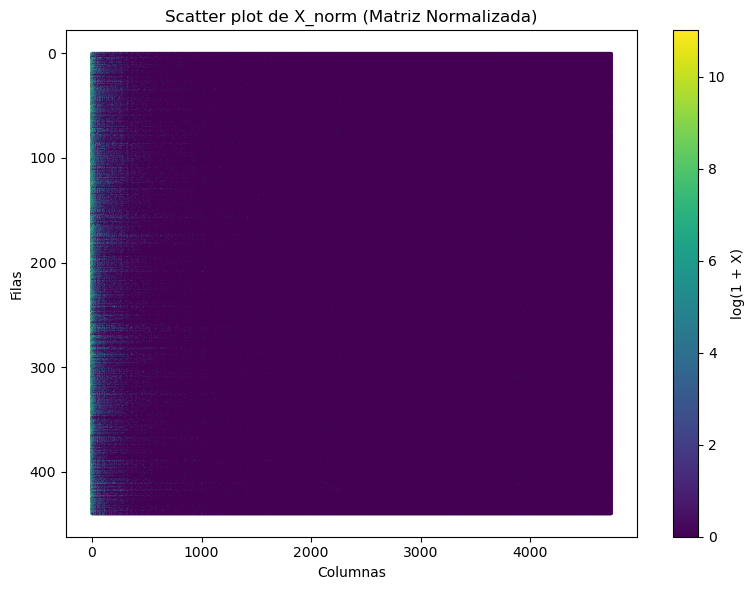

In [ ]:
# ==============================
# Bloque 3: Gráfico de puntos (scatter) de X_norm
# ==============================
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

# Si es vector 1D → puntos simples
if X_norm.ndim == 1:
    plt.scatter(np.arange(len(X_norm)), X_norm, s=25)
    plt.title("Scatter plot de X_norm (Vector Normalizado)")
    plt.xlabel("Índice")
    plt.ylabel("Valor Normalizado [0,1]")

# Si es matriz 2D → puntos por posición
elif X_norm.ndim == 2:
    filas, cols = X_norm.shape

    # Generar coordenadas de cada punto
    xs, ys = np.meshgrid(np.arange(cols), np.arange(filas))

    plt.scatter(xs.flatten(), ys.flatten(),
            c=np.log1p(X), cmap="viridis", s=1)

    plt.title("Scatter plot de X_norm (Matriz Normalizada)")
    plt.xlabel("Columnas")
    plt.ylabel("Filas")
    plt.gca().invert_yaxis()  # solo visual, opcional

else:
    raise ValueError("X_norm debe ser 1D o 2D.")

plt.colorbar(label="log(1 + X)")
plt.tight_layout()
plt.show()
